In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/javiuv/GenNN-InverseMicro
%cd GenNN-InverseMicro
!git checkout feature/dataset-preprocessing

Cloning into 'GenNN-InverseMicro'...
remote: Enumerating objects: 233, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (151/151), done.
remote: Total 233 (delta 113), reused 195 (delta 76), pack-reused 0 (from 0)
Receiving objects: 100% (233/233), 4.70 MiB | 12.51 MiB/s, done.
Resolving deltas: 100% (113/113), done.
/content/GenNN-InverseMicro
Branch 'feature/dataset-preprocessing' set up to track remote branch 'feature/dataset-preprocessing' from 'origin'.
Switched to a new branch 'feature/dataset-preprocessing'


In [3]:
!pip install torch torchvision tqdm pyyaml scikit-image pandas

In [4]:
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from torchvision import transforms
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

from src.architecture.vae import VAE
from src.reconstruction.vae_latent import VAELatentReconstructor

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

with open("/content/drive/MyDrive/pcam_project_new/configs/vae_training_used.yaml", "r") as f:
    train_cfg = yaml.safe_load(f)

model_params = train_cfg["model_params"]
pth_path = "/content/drive/MyDrive/pcam_project_new/models/vae/best_vae.pth"

print("Model params:", model_params)
print("Checkpoint path:", pth_path)

model = VAE(**model_params).to(device)
model.load_state_dict(torch.load(pth_path, map_location=device))
model.eval()

print("Model loaded successfully.")

Device: cpu
Model params: {'input_channels': 3, 'latent_dim': 64, 'hidden_dims': [32, 64, 128, 256], 'input_size': 96}
Checkpoint path: /content/drive/MyDrive/pcam_project_new/models/vae/best_vae.pth
Model loaded successfully.


In [6]:
with open("_config/vae_inference.yaml", "r") as f:
    infer_cfg = yaml.safe_load(f)

print(infer_cfg)

{'learning_rate': 0.01, 'num_steps': 1000, 'lambda_reg': 0.01}


In [7]:
test_clean_dir = Path("/content/drive/MyDrive/pcam_project/processed_denoising_final/test/clean")
test_noisy_dir = Path("/content/drive/MyDrive/pcam_project/processed_denoising_final/test/noisy")

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

clean_paths = sorted(list(test_clean_dir.glob("*.png")))
noisy_paths = sorted(list(test_noisy_dir.glob("*.png")))

print("Clean test images:", len(clean_paths))
print("Noisy test images:", len(noisy_paths))

Clean test images: 2000
Noisy test images: 2000


In [8]:
def load_image_tensor(img_path):
    img = Image.open(img_path).convert("RGB")
    return transform(img).unsqueeze(0).to(device)

def tensor_to_np(x):
    x = x.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
    x = np.clip(x, 0, 1)
    return x

def show_triplet(noisy_tensor, recon_tensor, clean_tensor, title_prefix=""):
    noisy_np = tensor_to_np(noisy_tensor)
    recon_np = tensor_to_np(recon_tensor)
    clean_np = tensor_to_np(clean_tensor)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(noisy_np)
    plt.title(f"{title_prefix} Noisy")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(recon_np)
    plt.title(f"{title_prefix} VAE Recon")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(clean_np)
    plt.title(f"{title_prefix} Clean GT")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def compute_metrics(recon_tensor, clean_tensor):
    recon_np = tensor_to_np(recon_tensor)
    clean_np = tensor_to_np(clean_tensor)

    mse = np.mean((recon_np - clean_np) ** 2)
    psnr = peak_signal_noise_ratio(clean_np, recon_np, data_range=1.0)
    ssim = structural_similarity(clean_np, recon_np, channel_axis=2, data_range=1.0)
    return mse, psnr, ssim

In [9]:
class IdentityOperator:
    def __call__(self, x):
        return x

100%|██████████| 200/200 [00:02<00:00, 92.60it/s]


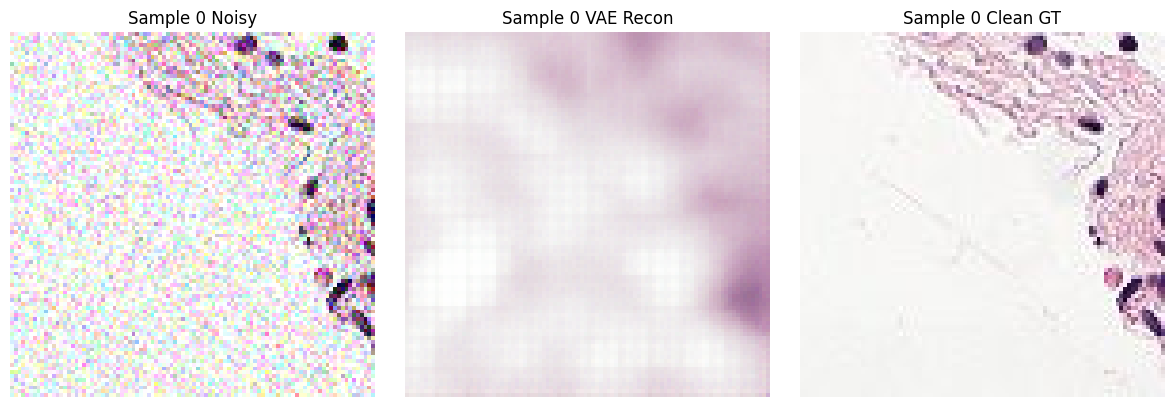

In [10]:
idx = 0

noisy_tensor = load_image_tensor(noisy_paths[idx])
clean_tensor = load_image_tensor(clean_paths[idx])

reconstructor = VAELatentReconstructor(model, IdentityOperator())

z_opt, recon_tensor = reconstructor.reconstruct(
    noisy_tensor,
    lr=infer_cfg["learning_rate"],
    num_steps=200,
    lambda_reg=infer_cfg["lambda_reg"]
)

show_triplet(noisy_tensor, recon_tensor, clean_tensor, title_prefix=f"Sample {idx}")

In [11]:
mse, psnr, ssim = compute_metrics(recon_tensor, clean_tensor)
print(f"MSE  : {mse:.6f}")
print(f"PSNR : {psnr:.4f}")
print(f"SSIM : {ssim:.4f}")

MSE  : 0.009838
PSNR : 20.0708
SSIM : 0.5569


In [12]:
results = []

for idx in range(5):
    noisy_tensor = load_image_tensor(noisy_paths[idx])
    clean_tensor = load_image_tensor(clean_paths[idx])

    z_opt, recon_tensor = reconstructor.reconstruct(
        noisy_tensor,
        lr=infer_cfg["learning_rate"],
        num_steps=200,
        lambda_reg=infer_cfg["lambda_reg"]
    )

    mse, psnr, ssim = compute_metrics(recon_tensor, clean_tensor)
    results.append((idx, mse, psnr, ssim))
    print(f"Sample {idx} | MSE={mse:.6f} | PSNR={psnr:.4f} | SSIM={ssim:.4f}")

100%|██████████| 200/200 [00:02<00:00, 96.77it/s]


Sample 0 | MSE=0.009837 | PSNR=20.0712 | SSIM=0.5568


100%|██████████| 200/200 [00:03<00:00, 62.12it/s]


Sample 1 | MSE=0.036207 | PSNR=14.4121 | SSIM=0.1105


100%|██████████| 200/200 [00:02<00:00, 73.20it/s]


Sample 2 | MSE=0.016751 | PSNR=17.7596 | SSIM=0.1202


100%|██████████| 200/200 [00:02<00:00, 97.65it/s]


Sample 3 | MSE=0.018730 | PSNR=17.2745 | SSIM=0.1071


100%|██████████| 200/200 [00:02<00:00, 96.07it/s]

Sample 4 | MSE=0.030549 | PSNR=15.1501 | SSIM=0.1499


In [13]:
avg_mse = np.mean([r[1] for r in results])
avg_psnr = np.mean([r[2] for r in results])
avg_ssim = np.mean([r[3] for r in results])

print("Average over 5 samples")
print(f"MSE  : {avg_mse:.6f}")
print(f"PSNR : {avg_psnr:.4f}")
print(f"SSIM : {avg_ssim:.4f}")

import os
results_dir = "/content/drive/MyDrive/pcam_project_new/results/metrics"
os.makedirs(results_dir, exist_ok=True)

df = pd.DataFrame(results, columns=["idx", "mse", "psnr", "ssim"])
df.to_csv(f"{results_dir}/vae_metrics_5samples.csv", index=False)
print("Saved metrics CSV.")

Average over 5 samples
MSE  : 0.022415
PSNR : 16.9335
SSIM : 0.2089
Saved metrics CSV.


100%|██████████| 200/200 [00:02<00:00, 96.89it/s]


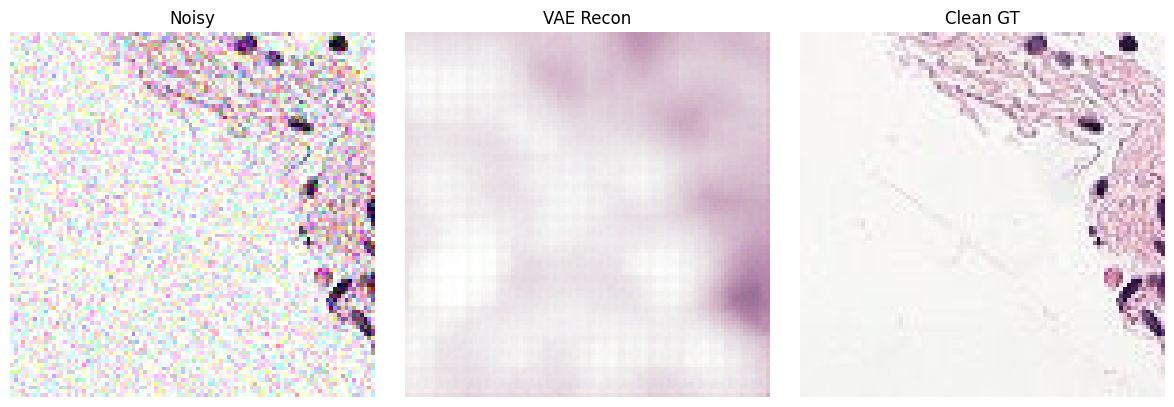

100%|██████████| 200/200 [00:02<00:00, 94.85it/s]


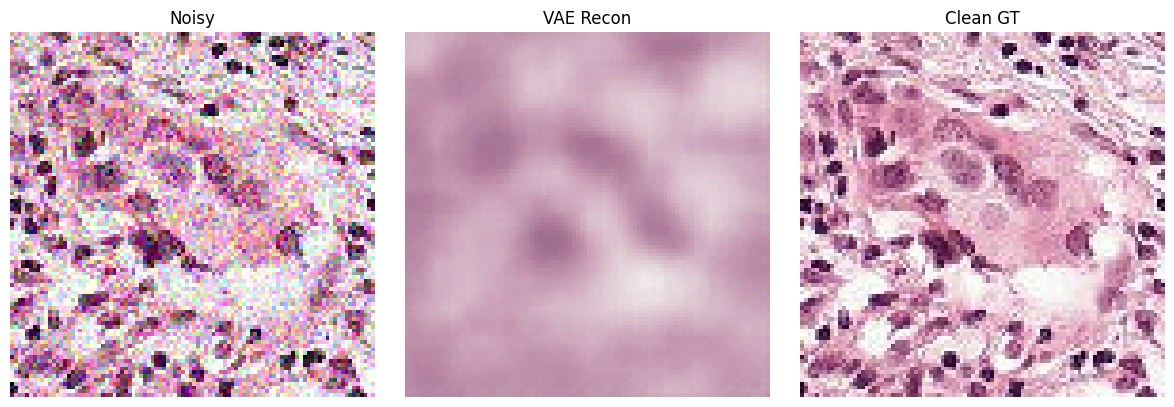

100%|██████████| 200/200 [00:03<00:00, 56.89it/s]


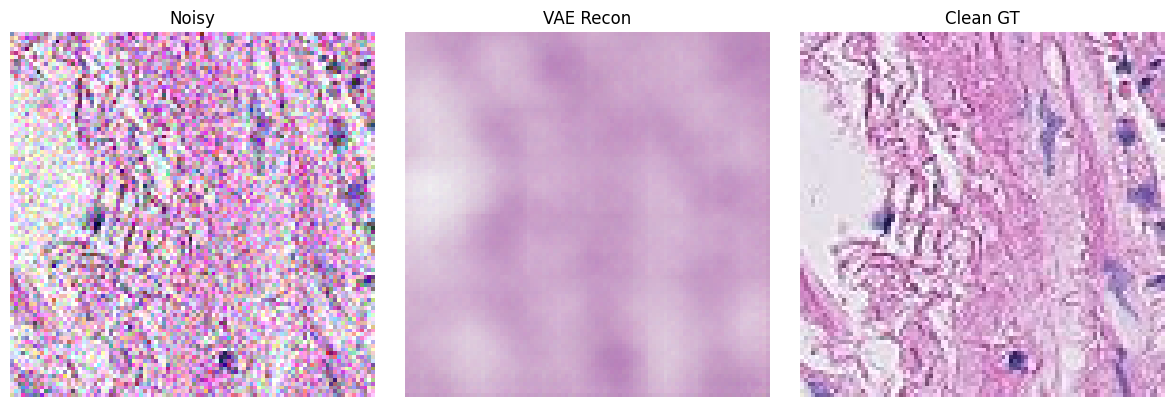

Saved reconstruction figures.


In [14]:
import os
os.makedirs("/content/drive/MyDrive/pcam_project_new/results/reconstructions", exist_ok=True)

for idx in [0, 1, 2]:
    noisy_tensor = load_image_tensor(noisy_paths[idx])
    clean_tensor = load_image_tensor(clean_paths[idx])

    z_opt, recon_tensor = reconstructor.reconstruct(
        noisy_tensor,
        lr=infer_cfg["learning_rate"],
        num_steps=200,
        lambda_reg=infer_cfg["lambda_reg"]
    )

    noisy_np = tensor_to_np(noisy_tensor)
    recon_np = tensor_to_np(recon_tensor)
    clean_np = tensor_to_np(clean_tensor)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(noisy_np)
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(recon_np)
    plt.title("VAE Recon")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(clean_np)
    plt.title("Clean GT")
    plt.axis("off")

    out_path = f"/content/drive/MyDrive/pcam_project_new/results/reconstructions/sample_{idx}_triplet.png"
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.show()

print("Saved reconstruction figures.")